In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import numpy as np
import pandas as pd
from glob import glob
from itertools import compress
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import os
os.environ["PROJ_LIB"] = "/opt/conda/share/proj"
os.environ["PROJ_DATA"] = "/opt/conda/share/proj"

# modeled vertical profile
files = glob("/data/project/ARM_Summer_School_2026/data/modeling/lasso/*/sgplassodiagconfobsmod*C1.m1/obs_model/sgplassomod*C1.m1.*.120000.nc")
in_paths = list(compress(files , [('5C1' not in f) for f in files]))
ds_z_mod_all = xr.open_mfdataset(in_paths, combine='nested', concat_dim = 'date')

In [2]:
ds_z_mod_all

<xarray.Dataset> Size: 208MB
Dimensions:                                  (date: 3, time: 273,
                                              south_north: 250, west_east: 250,
                                              height: 226)
Coordinates:
  * time                                     (time) datetime64[ns] 2kB 2018-0...
  * south_north                              (south_north) float32 1kB 0.0 .....
  * west_east                                (west_east) float32 1kB 0.0 ... ...
    height                                   (time, height) float32 247kB nan...
Dimensions without coordinates: date
Data variables: (12/22)
    base_time                                (date) datetime64[ns] 24B 2018-0...
    time_offset                              (date, time) datetime64[ns] 7kB dask.array<chunksize=(1, 5), meta=np.ndarray>
    low_cloud_fraction_arscl                 (date, time) float32 3kB dask.array<chunksize=(1, 5), meta=np.ndarray>
    lwp                                      (date, time) float32 3kB dask.array<chunksize=(1, 5), meta=np.ndarray>
    lcl                                      (date, time) float32 3kB dask.array<chunksize=(1, 5), meta=np.ndarray>
    water_vapor_mixing_ratio_surface         (date, time) float32 3kB dask.array<chunksize=(1, 5), meta=np.ndarray>
    ...                                       ...
    potential_temp                           (date, time, height) float32 740kB dask.array<chunksize=(1, 5, 226), meta=np.ndarray>
    water_vapor_mixing_ratio                 (date, time, height) float32 740kB dask.array<chunksize=(1, 5, 226), meta=np.ndarray>
    bar_pres                                 (date, time, height) float32 740kB dask.array<chunksize=(1, 5, 226), meta=np.ndarray>
    lat                                      (date) float32 12B 36.6 36.6 36.6
    lon                                      (date) float32 12B -97.49 ... -9...
    alt                                      (date) float32 12B 318.0 ... 318.0
Attributes: (12/38)
    Conventions:                           ARM-1.2
    command_line:                          lassomod -n lassomod8 -s sgp -f C1...
    process_version:                       vap-lassomod-1.3.1
    dod_version:                           lassomod8-m1-1.0
    input_datastreams:                     sgpwrfout8C1.m0 : 1.0 : 20180709.1...
    site_id:                               sgp
    ...                                    ...
    config_nickname:                       runlas20180709v1msda2d300km
    boundary_layer_top:                    700.0 m AGL
    boundary_layer_bottom:                 500.0 m AGL
    history:                               Tue Oct 13 20:03:16 2020: ncrcat /...
    NCO:                                   netCDF Operators version 4.7.5 (Ho...
    nco_openmp_thread_number:              1

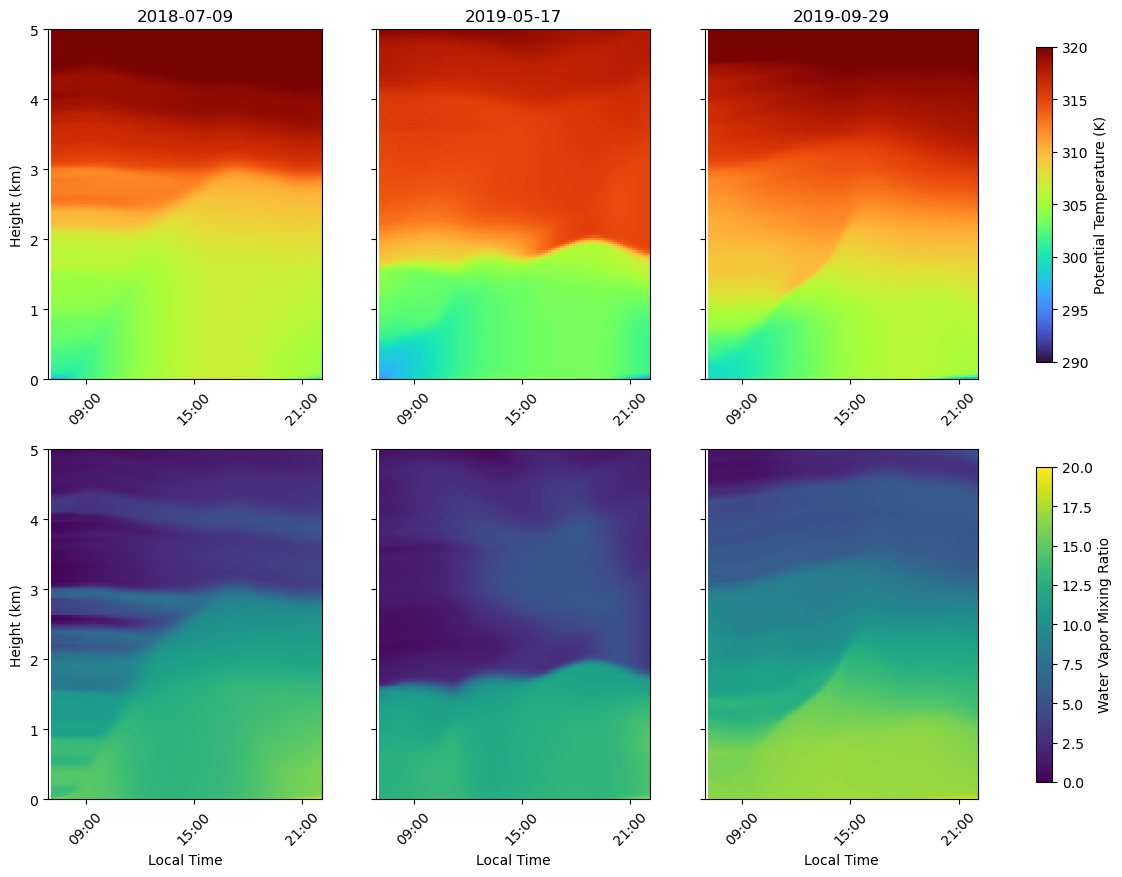

In [3]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 10),
    sharex=False,
    sharey=True
)

# height
z = ds_z_mod_all["height"].mean(dim="time", skipna=True)

# if height in meters:
if z.max() > 100:
    z = z / 1000

keep = np.isfinite(z.values) & (z.values <= 5)

# variables and settings
vars_info = [
    {
        "var": "potential_temp",
        "vmin": 290,
        "vmax": 320,
        "cmap": "turbo",
        "label": "Potential Temperature (K)"
    },
    {
        "var": "water_vapor_mixing_ratio",
        "vmin": 0,
        "vmax": 20,
        "cmap": "viridis",
        "label": "Water Vapor Mixing Ratio"
    }
]

for row, info in enumerate(vars_info):

    var = info["var"]

    for i in range(3):

        ax = axes[row, i]

        da = ds_z_mod_all[var].isel(date=i).isel(height=keep)
        z_low = z.isel(height=keep)

        x = pd.to_datetime(ds_z_mod_all["time_offset"].isel(date=i).values)
        x_local = (x.tz_localize("UTC").tz_convert("US/Central").tz_localize(None))

        y = z_low.values

        c = da.transpose("height", "time").values

        # remove bad times
        good_x = pd.notnull(x_local)
        x_local = x_local[good_x]
        c = c[:, good_x]

        mesh = ax.pcolormesh(
            x_local,
            y,
            c,
            shading="auto",
            vmin=info["vmin"],
            vmax=info["vmax"],
            cmap=info["cmap"]
        )

        # titles on top row
        if row == 0:
            date_label = str(
                ds_z_mod_all["base_time"]
                .isel(date=i)
                .values
            )[:10]

            ax.set_title(date_label)

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%H:%M")
        )

        ax.xaxis.set_major_locator(
            mdates.HourLocator(interval=6)
        )

        plt.setp(
            ax.xaxis.get_majorticklabels(),
            rotation=45
        )

        ax.set_ylim(0, 5)

        if i == 0:
            ax.set_ylabel("Height (km)")

        if row == 1:
            ax.set_xlabel("Local Time")

    # colorbar
    fig.colorbar(
        mesh,
        ax=axes[row, :],
        label=info["label"],
        shrink=0.9
    )

plt.show()

In [4]:
print(ds_z_mod_all["time_offset"])

<xarray.DataArray 'time_offset' (date: 3, time: 273)> Size: 7kB
dask.array<concatenate, shape=(3, 273), dtype=datetime64[ns], chunksize=(1, 5), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2kB 2018-07-09T12:00:00 ... 2019-09-30T03:...
Dimensions without coordinates: date
Attributes:
    long_name:            Time offset from base_time
    ancillary_variables:  base_time
